# Read dataset

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
from PreProcessingData.datasets import DATASET
from imblearn.over_sampling import SMOTE

In [10]:
path = 'Dataset/K_folds_dataset/' + DATASET.name
print("Loading data from: ", path)
FEATURES =['lex_sim', 'sem_sim', 'sim_bug', 'fix_freq']

def load_data(fold):
    df = pd.read_csv(path + '/fold_' + str(fold) + '.csv')
    X = df[FEATURES].values
    y = df['label'].values
    bug_id = df['bug_id'].values

    return X, y, bug_id

X, y, bug = load_data(1)
print(type(X))
print(type(y))
print("X: ", X)
print("y: ", y)
print(X[y == 1].shape)
print(X[y == 0].shape)
print(type(X))
print(type(y))


Loading data from:  Dataset/K_folds_dataset/eclipse
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
X:  [[0.01542176 0.66608214 0.         0.        ]
 [0.01107103 0.71473545 0.         0.        ]
 [0.01184913 0.6501879  0.         0.        ]
 ...
 [0.00363939 0.7709586  0.         0.        ]
 [0.00490234 0.6465146  0.         0.        ]
 [0.00150617 0.7768726  0.         0.        ]]
y:  [0 0 0 ... 0 0 0]
(128, 4)
(4000957, 4)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [11]:
X_data = []
y_data = []
bug_data = []
for fold in range(1, 11):
    X_fold, y_fold, bug_fold = load_data(fold)
    X_data.append(X_fold)
    y_data.append(y_fold)
    bug_data.append(bug_fold)


# Focal loss
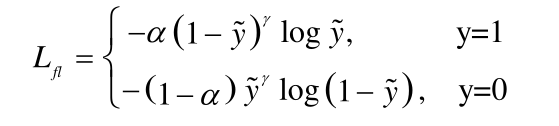

In [12]:
from torch import nn, optim
import torch

class FocalLoss(nn.Module):
    """
    FL = - alpha * y * (1-p)^gamma * log(p) - (1-alpha) * (1-y) * p^gamma * log(1-p)
    y in {0,1}, p = sigmoid(logits)
    """
    def __init__(self, alpha: float = 0.999, gamma: float = 2.0, reduction: str = "mean", eps: float = 1e-7):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.eps = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        p = torch.sigmoid(logits).clamp(self.eps, 1 - self.eps)
        y = targets
        loss_pos = - self.alpha * (1 - p).pow(self.gamma) * torch.log(p) * y
        loss_neg = - (1 - self.alpha) * (p).pow(self.gamma) * torch.log(1 - p) * (1 - y)
        loss = loss_pos + loss_neg
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

# Bootstrapping

In [13]:
# class BootstrappedBatchSampler:
#     def __init__(self, pos_idx: np.ndarray, neg_idx: np.ndarray, sn=1000, sp=100):
#         self.pos_idx = pos_idx
#         self.neg_idx = neg_idx
#         self.sn = sn
#         self.sp = sp
#     def __iter__(self):
#         rng = np.random.default_rng()
#         neg = self.neg_idx.copy()
#         rng.shuffle(neg)
#         for start in range(0, len(neg), self.sn):
#             nb = neg[start:start+self.sn]
#             pb = rng.choice(self.pos_idx, size=self.sp, replace=True)
#             batch = np.concatenate([nb, pb])
#             rng.shuffle(batch)
#             yield batch
#     def __len__(self):  # số batch/epoch xấp xỉ
#         return max(1, int(np.ceil(len(self.neg_idx) / self.sn)))

rng = np.random.default_rng(42)
def bootstrap(pos_idx: np.ndarray, neg_idx: np.ndarray, n_pos = 50, n_neg = 300):
    
    pos_sample = rng.choice(pos_idx, size=n_pos, replace=True)
    neg_sample = rng.choice(neg_idx, size=n_neg, replace=True)
    batch = np.concatenate([pos_sample, neg_sample])
    rng.shuffle(batch)
    return batch

# Build model

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import BCELoss

class DNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(in_features=input_dim, out_features=300), nn.ReLU(), 
            nn.Linear(in_features=300, out_features=150), nn.ReLU(),
            nn.Linear(in_features=150, out_features=1), nn.Sigmoid()
        )
    def forward(self, x):
        logits = self.sequential(x)
        return logits
    



# Evalulation

In [15]:
def eval_grouped(scores: torch.Tensor, labels: torch.Tensor, bug_codes: torch.Tensor, ks=(1,5,10,15)):

    scores = scores.detach().flatten()                
    labels = labels.detach().to(torch.long).flatten()
    bug_codes = bug_codes.detach().to(torch.long).flatten()

    uniq = torch.unique(bug_codes)
    hit_at = {k: [] for k in ks}
    rr_list, ap_list = [], []

    for g in uniq:
        s = scores[bug_codes == g].flatten()
        y = labels[bug_codes == g].flatten()

        order = torch.argsort(s, descending=True)
        y_ord = y[order]

        # Top-k 
        for k in ks:
            hit_at[k].append(1.0 if (y_ord[:k] == 1).any() else 0.0)

        # MRR
        pos = torch.nonzero(y_ord == 1, as_tuple=False).squeeze(1) # postive positions
        rr_list.append(float(1.0 / (pos[0].item() + 1)) if pos.numel() > 0 else 0.0)

        # MAP
        hits, precs = 0, []
        for rank, lab in enumerate(y_ord.tolist(), start=1):
            if lab == 1:
                hits += 1
                precs.append(hits / rank)
        ap_list.append(float(np.mean(precs)) if precs else 0.0)

    out = {f"Top@{k}": float(np.mean(hit_at[k])) if hit_at[k] else 0.0 for k in ks}
    out["MRR"] = float(np.mean(rr_list)) if rr_list else 0.0
    out["MAP"] = float(np.mean(ap_list)) if ap_list else 0.0
    return out

# Training

In [ ]:

EPOCHS = 30

top1_list = []
top5_list = []
top10_list = []
top15_list = []
MRR_list = []
MAP_list = []

for i in range(len(X_data) - 1):
    cols = [0, 2, 5]
    
    X_train = X_data[i][:, cols]
    X_test  = X_data[i+1][:, cols]
    y_train = y_data[i]
    y_test  = y_data[i+1]

    #     #Smote peen
    # smote = SMOTE(random_state=42)
    # X_train, y_train = smote.fit_resample(X_train, y_train)

    # Min–Max fit trên TRAIN, transform cả TRAIN và TEST
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    X_train_t = torch.from_numpy(X_train).to(device)
    y_train_t = torch.from_numpy(y_train).to(device)
    X_test_t = torch.from_numpy(X_test).to(device)
    y_test_t = torch.from_numpy(y_test).to(device)


    pos_idx = np.flatnonzero(y_train == 1)
    neg_idx = np.flatnonzero(y_train == 0)

    net = DNN(X_train.shape[1])
    net.to(device)
    criterion = FocalLoss()
    optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

    for ep in range(1, EPOCHS + 1):
        # training
        net.train()
        total_loss = 0.0
        steps_per_epoch = int(np.ceil(len(neg_idx) / 300))

        for step in range(steps_per_epoch):
            batch_idx = bootstrap(pos_idx, neg_idx)
            xb = X_train_t[batch_idx]
            yb = y_train_t[batch_idx].float()
            # print(len(np.flatnonzero(yb == 1)))

            optimizer.zero_grad()
            output = net(xb)     
            # print(output.shape, yb.shape)
            loss = criterion(output.squeeze(1), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()   

        avg_loss = total_loss / steps_per_epoch
        # print(f"Epoch {ep:02d} | loss={avg_loss:.4f}")

    # testing
    net.eval()
    with torch.no_grad():
        res = net(X_test_t).squeeze(1)        


    # group theo bug_id trên TEST
    bug_id_test = bug_data[i+1]
    bug_codes = torch.tensor(                                                                                                               
        pd.factorize(bug_id_test)[0],
        device=res.device
    )

    metrics = eval_grouped(res, y_test_t, bug_codes, ks=(1,5,10,15))
    print(f"[Fold {i + 1}->{i + 2} | Epoch {ep:02d}] "
            # f"loss={avg_loss:.4f} | "
            f"Top1={metrics['Top@1']:.3f} Top5={metrics['Top@5']:.3f} "                                                                           
            f"Top10={metrics['Top@10']:.3f} Top15={metrics['Top@15']:.3f} "
            f"MRR={metrics['MRR']:.3f} MAP={metrics['MAP']:.3f}")

    top1_list.append(metrics['Top@1'])
    top5_list.append(metrics['Top@5'])
    top10_list.append(metrics['Top@10'])
    top15_list.append(metrics['Top@15'])
    MRR_list.append(metrics['MRR'])
    MAP_list.append(metrics['MAP'])    
    

In [ ]:
print("Final Average Results over all folds:")
print(f"Top1={np.mean(top1_list):.3f} Top5={np.mean(top5_list):.3f} "                                                                           
      f"Top10={np.mean(top10_list):.3f} Top15={np.mean(top15_list):.3f} "
      f"MRR={np.mean(MRR_list):.3f} MAP={np.mean(MAP_list):.3f}")   

Final Average Results over all folds:
Top1=0.043 Top5=0.157 Top10=0.256 Top15=0.355 MRR=0.115 MAP=0.115


# Save model hyperprameter

In [ ]:
PATH = DATASET.name + ".pth"
torch.save(net.state_dict(), PATH)